銘柄数: 3773
['1301.T', '130A.T', '1332.T', '1333.T', '135A.T', '1375.T', '1376.T', '1377.T', '1379.T', '137A.T', '1380.T', '1381.T', '1382.T', '1383.T', '1384.T', '138A.T', '1401.T', '1407.T', '1414.T', '1417.T', '1418.T', '1419.T', '141A.T', '1420.T', '1429.T', '142A.T', '1430.T', '1431.T', '1433.T', '1434.T', '1435.T', '1436.T', '1438.T', '143A.T', '1443.T', '1444.T', '1446.T', '1447.T', '1450.T', '145A.T', '146A.T', '147A.T', '148A.T', '1491.T', '149A.T', '150A.T', '1514.T', '1515.T', '1518.T', '151A.T', '153A.T', '155A.T', '156A.T', '157A.T', '1605.T', '160A.T', '1662.T', '1663.T', '166A.T', '167A.T', '168A.T', '1711.T', '1716.T', '1717.T', '1718.T', '1719.T', '1720.T', '1721.T', '1723.T', '1724.T', '1726.T', '1736.T', '173A.T', '1758.T', '175A.T', '1762.T', '1764.T', '1766.T', '1768.T', '1770.T', '1773.T', '1776.T', '177A.T', '1780.T', '1783.T', '1786.T', '1787.T', '1788.T', '1793.T', '1795.T', '1798.T', '1799.T', '1801.T', '1802.T', '1803.T', '1807.T', '1808.T', '1810.T', '1811.T',

,ticker,strategy_return,buy_hold_return,alpha,entry_count
2964,7944.T,1.844975,-1.029476e+02,1.047926e+02,12
989,3856.T,21.904074,2.354903e+00,1.954917e+01,12
2015,6195.T,10.029532,7.638491e-01,9.265683e+00,10
1756,5535.T,8.651755,3.421573e+00,5.230182e+00,12
1036,3936.T,5.766383,1.001335e+00,4.765048e+00,10
...,...,...,...,...,...
111,1841.T,0.901670,1.367211e+05,-1.367202e+05,16
2799,7635.T,488341.106608,7.647778e+05,-2.764367e+05,17
890,3655.T,1.171795,3.699221e+06,-3.699220e+06,19
325,2389.T,1.288297,6.937234e+06,-6.937233e+06,16


,ticker,strategy_return,buy_hold_return,alpha,entry_count
2964,7944.T,1.844975,-102.947630,104.792605,12
989,3856.T,21.904074,2.354903,19.549171,12
2015,6195.T,10.029532,0.763849,9.265683,10
1756,5535.T,8.651755,3.421573,5.230182,12
1036,3936.T,5.766383,1.001335,4.765048,10
3420,9268.T,8.610772,4.013349,4.597423,13
2820,7692.T,5.703355,1.478709,4.224646,8
971,3825.T,4.074086,0.254759,3.819328,11
461,2767.T,6.661086,3.827052,2.834034,17
3002,8002.T,10.459304,7.732662,2.726642,10


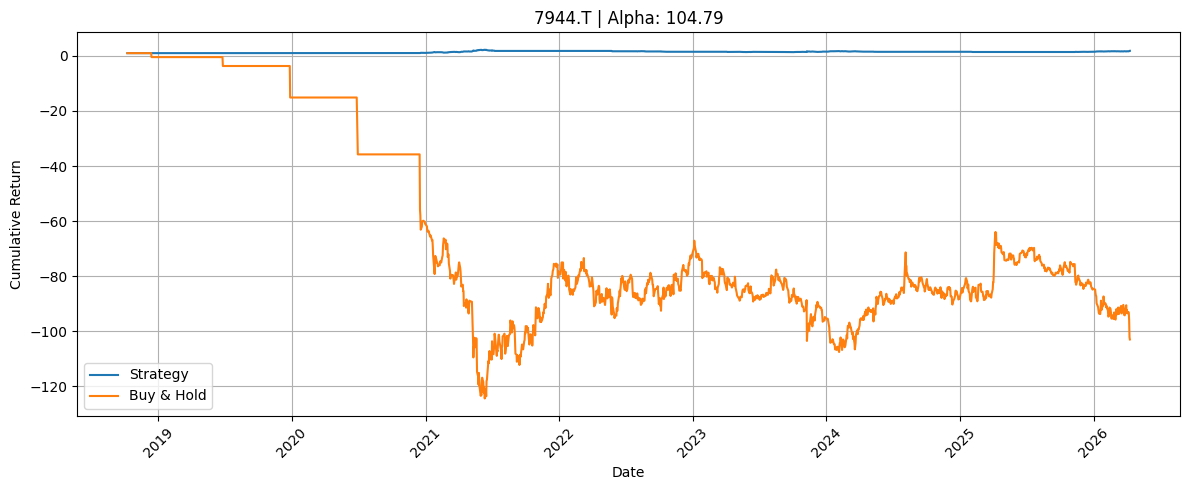

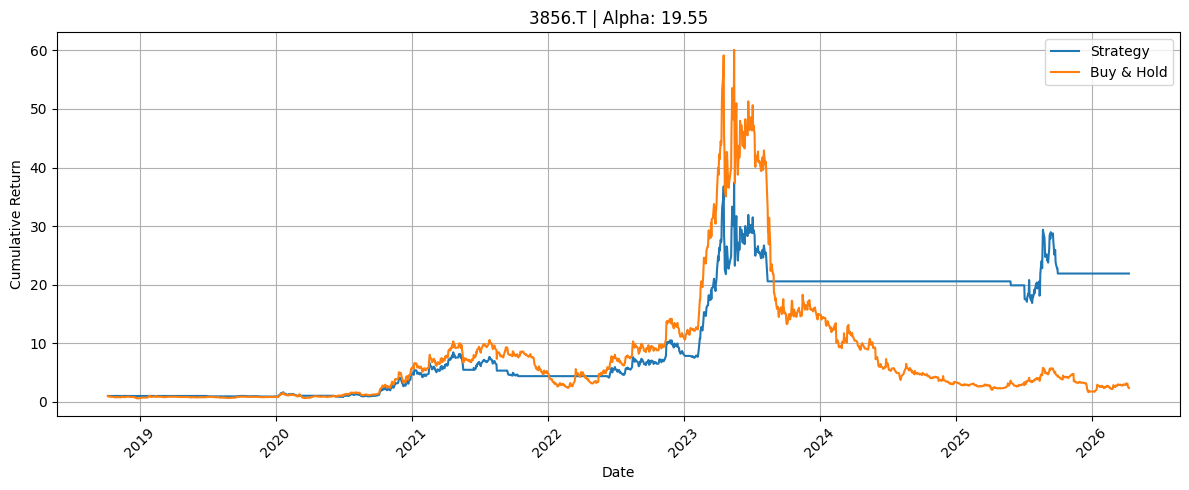

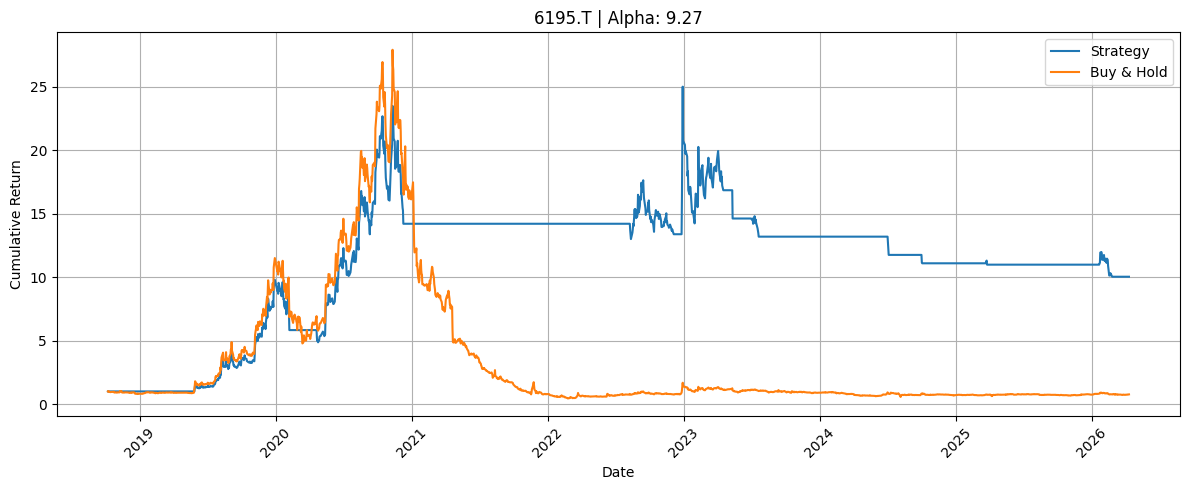

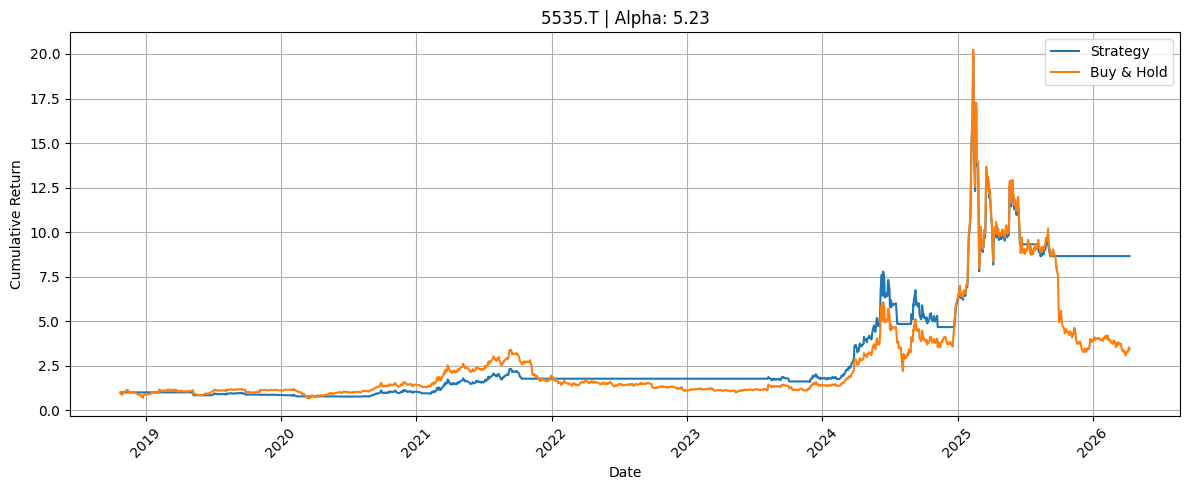

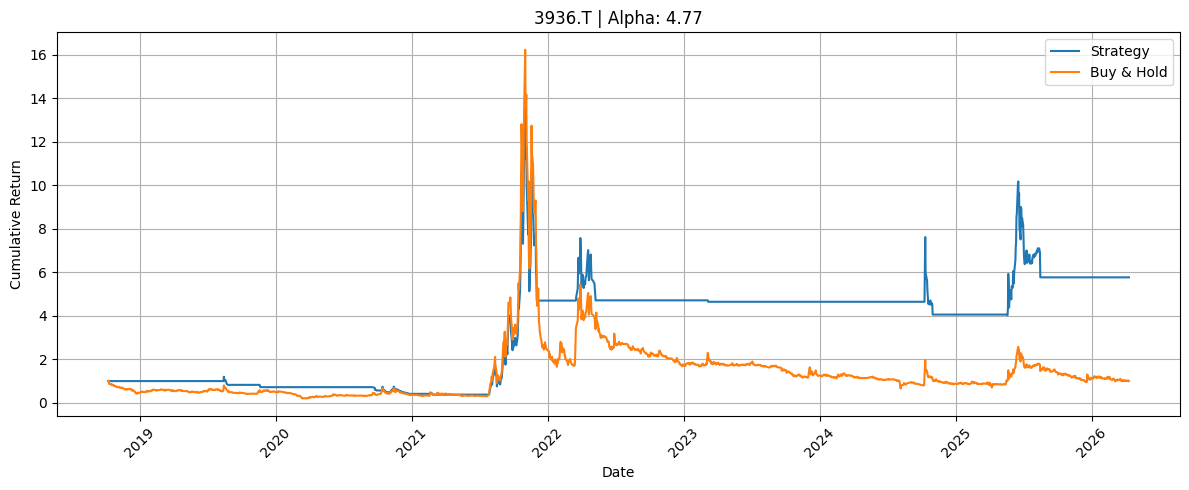

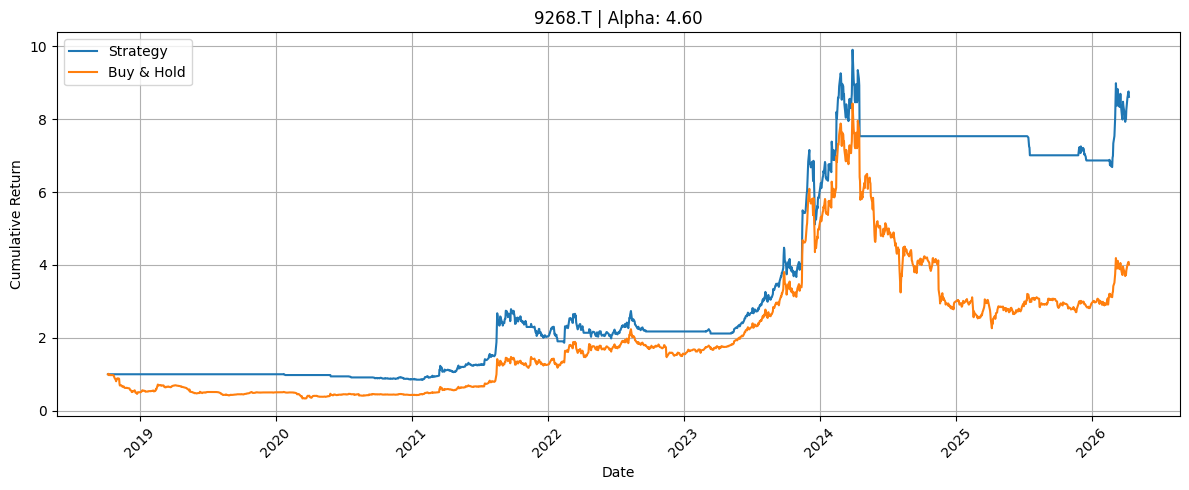

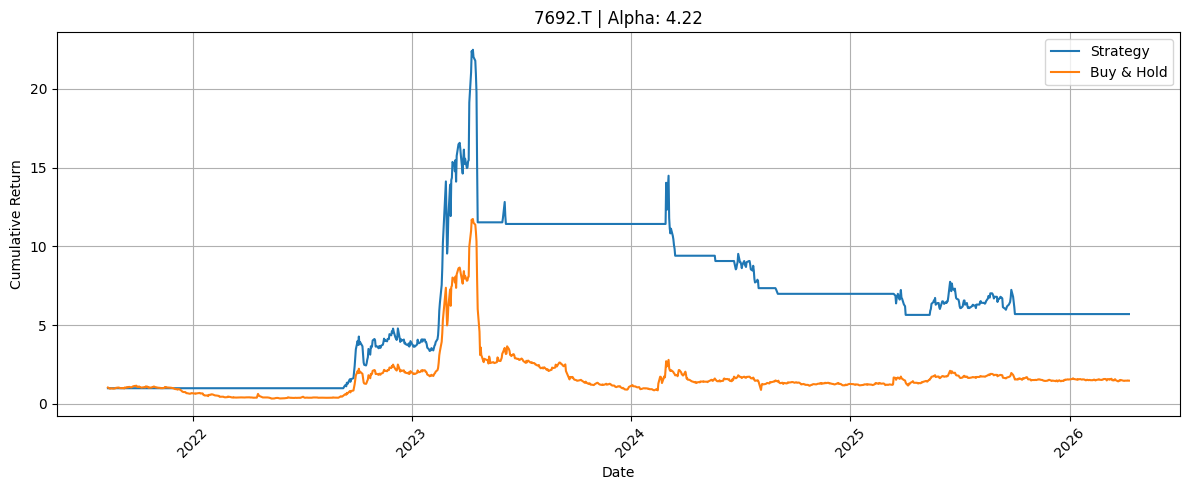

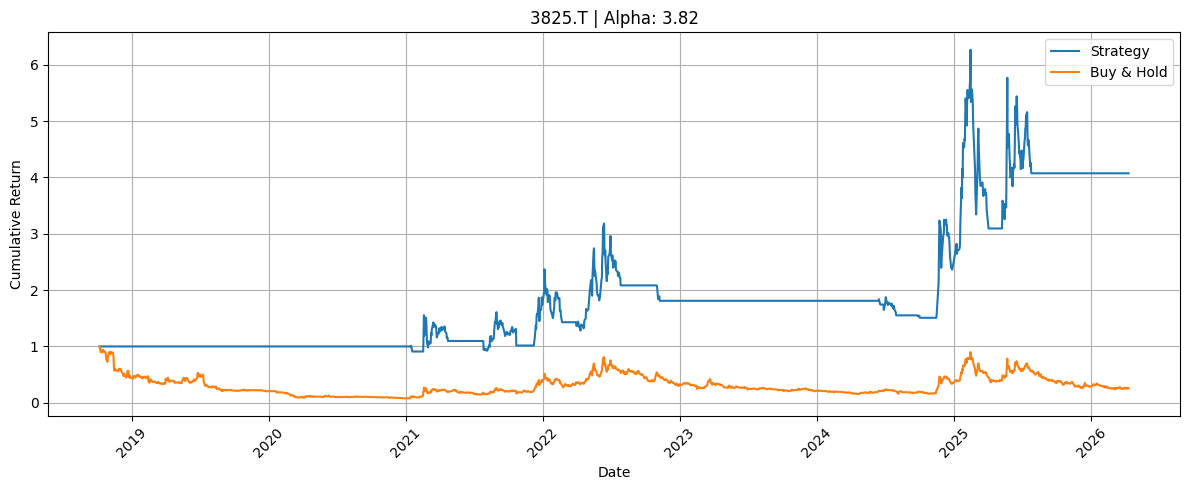

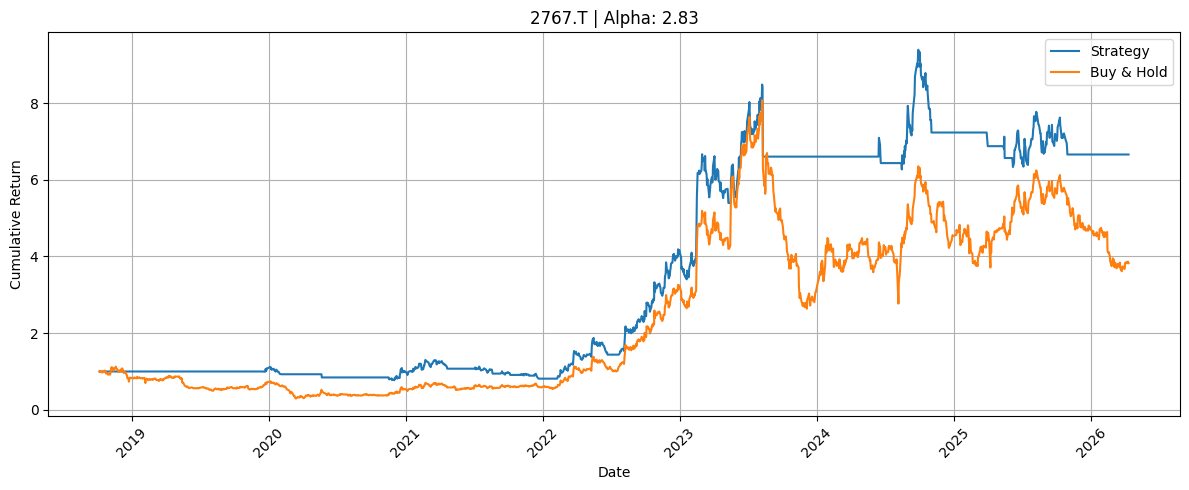

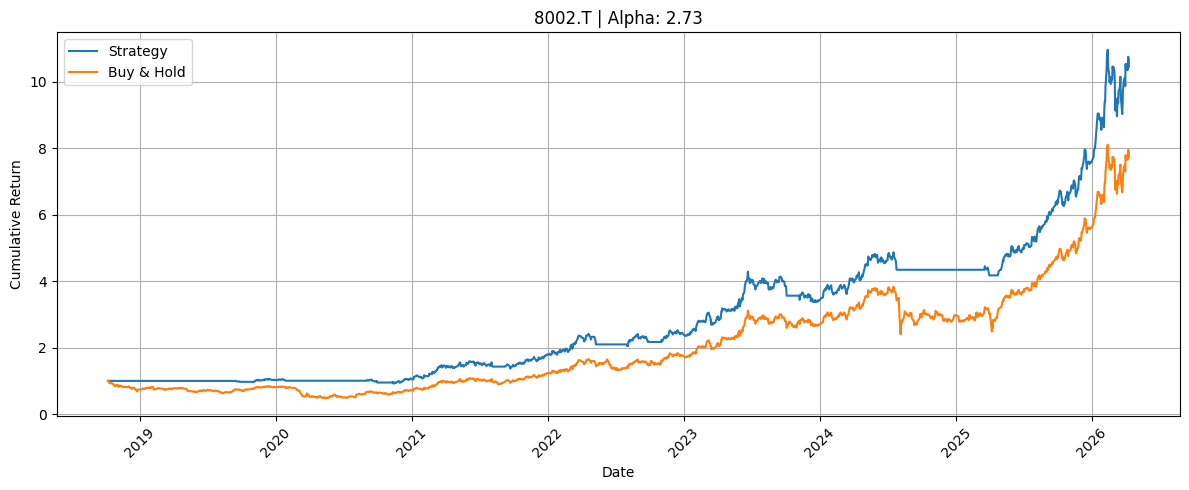

In [52]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
conn = sqlite3.connect("all_stocks.db")

#株価売買戦略
def load_stock_data(ticker):
    query = f"""
    SELECT *
    FROM stock_price
    WHERE ticker = '{ticker}'
    ORDER BY date
    """
    df = pd.read_sql(query, conn)
    df["date"] = pd.to_datetime(df["date"])
    return df


def create_signal(df):
    # 指標
    df["high_15"] = df["high"].rolling(15).max()
    df["low_30"] = df["low"].rolling(30).min()
    df["vol_ma"] = df["volume"].rolling(20).mean()


    df["ma_25"] = df["close"].rolling(25).mean()
    df["ma_200"] = df["close"].rolling(200).mean()

    breakout = df["close"] > df["high_15"].shift(1)
    volume_confirm = df["volume"] > df["vol_ma"]
    short_trend = df["close"] > df["ma_25"]
    long_trend = df["close"] > df["ma_200"]


    df["signal"] = pd.NA

    # 買いサイン
    df.loc[
        breakout 
        & volume_confirm
        & short_trend
        & long_trend,
        "signal"
    ] = 1

    # 売りサイン
    df.loc[
        df["close"] < df["low_30"].shift(1),
        "signal"
    ] = 0

    # 長期トレンド崩れ撤退
    df.loc[
        df["close"] < df["ma_200"],
        "signal"
    ] = 0

    # ポジション
    df["position"] = (
        df["signal"]
        .ffill()
        .fillna(0)
        .shift(1)
    )

    df["new_entry"] = (
        (df["position"] == 1)
        & (df["position"].shift(1) == 0)
    )

    df["new_exit"] = (
    (df["position"] == 0)
    & (df["position"].shift(1) == 1))

    # エントリー価格
    df["entry_price"] = pd.NA
    df.loc[df["new_entry"], "entry_price"] = df["close"]
    df["entry_price"] = df["entry_price"].ffill()
    df.loc[df["position"] == 0, "entry_price"] = pd.NA
    df = df.dropna(subset=["ma_200"]).copy()
    return df


results={}


query = """
SELECT DISTINCT ticker
FROM stock_price 
ORDER BY ticker
"""
tickers_df = pd.read_sql(query, conn)
tickers = tickers_df["ticker"].tolist()
print("銘柄数:", len(tickers))
print(tickers[:3500])


tickers = tickers[:3500]
for ticker in tickers:
    df = load_stock_data(ticker)
    df = create_signal(df)
    results[ticker] = df

for ticker, df in results.items():
 #   print(ticker)
 #   print(df["signal"].value_counts())

    df["return"] = df["close"].pct_change()
    # 戦略リターン
    df["strategy_return"] = df["position"] * df["return"]
    # 累積
    df["cum_return"] = (1 + df["strategy_return"]).cumprod()
    # 比較
    df["buy_hold"] = (1 + df["return"]).cumprod()
 #   display(df.tail(3))
 #   print("エントリー回数:", df["new_entry"].sum())
    results[ticker] = df


#勝利分析
summary = []
for ticker, df in results.items():

    if df.empty:
        print(f"skip empty: {ticker}")
        continue

    strategy_final = df["cum_return"].iloc[-1]
    buy_hold_final = df["buy_hold"].iloc[-1]
    entry_count = df["new_entry"].sum()

    summary.append({
        "ticker": ticker,
        "strategy_return": strategy_final,
        "buy_hold_return": buy_hold_final,
        "alpha": strategy_final - buy_hold_final,
        "entry_count": entry_count
    })


summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("alpha", ascending=False)
display(summary_df)


top10 = summary_df.sort_values("alpha", ascending=False).head(10)
display(top10)

for ticker in top10["ticker"]:
    df = results[ticker]
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["cum_return"], label="Strategy")
    plt.plot(df["date"], df["buy_hold"], label="Buy & Hold")
    alpha = df["cum_return"].iloc[-1] - df["buy_hold"].iloc[-1]
    plt.title(f"{ticker} | Alpha: {alpha:.2f}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



export_cols = [
    "date",
    "close",
    "signal",
    "position",
    "new_entry",
    "entry_price",
    "strategy_return",
    "cum_return",
    "buy_hold",
    "new_exit"
]

#エクセル出力用
#with pd.ExcelWriter("backtest_results_all.xlsx") as writer:
#    for ticker, df in results.items():
#        df[export_cols].to_excel(writer, sheet_name=ticker.replace(".T", ""))    


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

7203.T
signal
0    429
1     76
Name: count, dtype: int64


,Close,High,Low,Open,Volume,high_15,low_30,vol_ma,ma_25,trend_flag,ma_200,long_trend,signal,position,new_entry,entry_price,return,strategy_return,cum_return,buy_hold
Date,,,,,,,,,,,,,,,,,,,,
2026-04-06,3247.0,3297.0,3244.0,3255.0,11430400,3384.0,3143.198179,20286465.0,3359.094463,False,3038.340504,True,<NA>,0,False,<NA>,-0.002458,-0.0,1.540579,2.593739
2026-04-07,3252.0,3264.0,3224.0,3235.0,14215500,3384.0,3143.198179,19586050.0,3333.729023,False,3041.713634,True,<NA>,0,False,<NA>,0.001540,0.0,1.540579,2.597733
2026-04-08,3384.0,3418.0,3333.0,3392.0,27222600,3418.0,3143.198179,19836075.0,3323.181562,True,3045.938417,True,<NA>,0,False,<NA>,0.040590,0.0,1.540579,2.703176
2026-04-09,3331.0,3399.0,3318.0,3398.0,20191400,3418.0,3143.198179,20085250.0,3317.687295,True,3050.196597,True,<NA>,0,False,<NA>,-0.015662,-0.0,1.540579,2.660839
2026-04-10,3319.0,3363.0,3295.0,3345.0,16930900,3418.0,3143.198179,19965045.0,3313.250137,True,3054.397202,True,<NA>,0,False,<NA>,-0.003603,-0.0,1.540579,2.651253


エントリー回数: 14
3914.T
signal
0    975
1     41
Name: count, dtype: int64


,Close,High,Low,Open,Volume,high_15,low_30,vol_ma,ma_25,trend_flag,ma_200,long_trend,signal,position,new_entry,entry_price,return,strategy_return,cum_return,buy_hold
Date,,,,,,,,,,,,,,,,,,,,
2026-04-06,2600.0,2606.0,2508.0,2528.0,19000,2606.0,2250.0,11985.0,2411.32,True,2657.160,False,0,0,False,<NA>,0.031746,0.0,0.654788,0.595647
2026-04-07,2612.0,2672.0,2582.0,2601.0,20600,2672.0,2250.0,12110.0,2418.20,True,2656.120,False,0,0,False,<NA>,0.004615,0.0,0.654788,0.598396
2026-04-08,2685.0,2685.0,2632.0,2651.0,13500,2685.0,2250.0,12425.0,2430.08,True,2655.695,True,1,0,False,<NA>,0.027948,0.0,0.654788,0.615120
2026-04-09,2698.0,2705.0,2655.0,2700.0,14000,2705.0,2250.0,12775.0,2446.12,True,2655.585,True,1,1,True,2698.0,0.004842,0.004842,0.657959,0.618099
2026-04-10,2743.0,2760.0,2702.0,2703.0,13500,2760.0,2250.0,12955.0,2460.64,True,2655.605,True,1,1,False,2698.0,0.016679,0.016679,0.668933,0.628408


エントリー回数: 10
7779.T
signal
0    993
1     30
Name: count, dtype: int64


,Close,High,Low,Open,Volume,high_15,low_30,vol_ma,ma_25,trend_flag,ma_200,long_trend,signal,position,new_entry,entry_price,return,strategy_return,cum_return,buy_hold
Date,,,,,,,,,,,,,,,,,,,,
2026-04-06,270.0,278.0,270.0,275.0,1164200,329.0,263.0,2251630.0,306.20,False,218.300,True,<NA>,0,False,<NA>,-0.007353,-0.0,0.510024,0.486486
2026-04-07,268.0,281.0,264.0,275.0,1534500,329.0,263.0,2130480.0,302.44,False,218.775,True,<NA>,0,False,<NA>,-0.007407,-0.0,0.510024,0.482883
2026-04-08,290.0,291.0,272.0,276.0,2675000,329.0,263.0,2120200.0,300.44,False,219.365,True,<NA>,0,False,<NA>,0.082090,0.0,0.510024,0.522523
2026-04-09,279.0,287.0,276.0,287.0,1562700,317.0,263.0,1991990.0,298.80,False,219.900,True,<NA>,0,False,<NA>,-0.037931,-0.0,0.510024,0.502703
2026-04-10,277.0,287.0,276.0,280.0,1381000,311.0,263.0,1894670.0,296.36,False,220.410,True,<NA>,0,False,<NA>,-0.007168,-0.0,0.510024,0.499099


エントリー回数: 12
2586.T
signal
0    956
1     30
Name: count, dtype: int64


,Close,High,Low,Open,Volume,high_15,low_30,vol_ma,ma_25,trend_flag,ma_200,long_trend,signal,position,new_entry,entry_price,return,strategy_return,cum_return,buy_hold
Date,,,,,,,,,,,,,,,,,,,,
2026-04-06,111.0,112.0,111.0,112.0,295300,121.0,109.0,944045.0,114.80,False,201.650,False,0,0,False,<NA>,-0.008929,-0.0,1.025575,0.399281
2026-04-07,112.0,113.0,111.0,112.0,325500,120.0,109.0,889845.0,114.56,False,201.415,False,0,0,False,<NA>,0.009009,0.0,1.025575,0.402878
2026-04-08,117.0,117.0,113.0,113.0,1597200,120.0,109.0,930990.0,114.60,True,201.195,False,0,0,False,<NA>,0.044643,0.0,1.025575,0.420863
2026-04-09,113.0,117.0,112.0,117.0,729600,120.0,109.0,875030.0,114.72,False,200.945,False,0,0,False,<NA>,-0.034188,-0.0,1.025575,0.406475
2026-04-10,112.0,113.0,111.0,113.0,1020200,120.0,109.0,868035.0,114.68,False,200.710,False,0,0,False,<NA>,-0.008850,-0.0,1.025575,0.402878


エントリー回数: 9


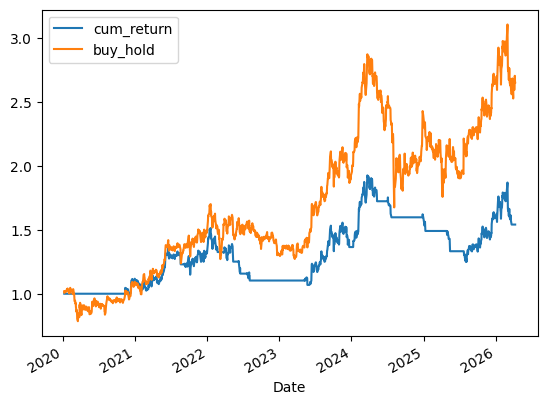

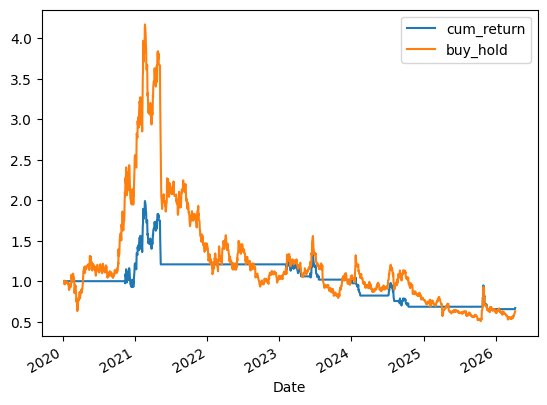

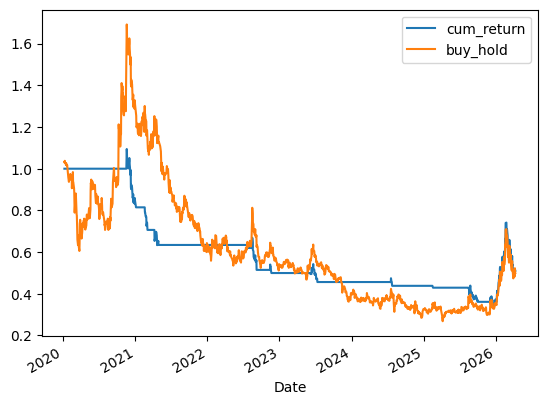

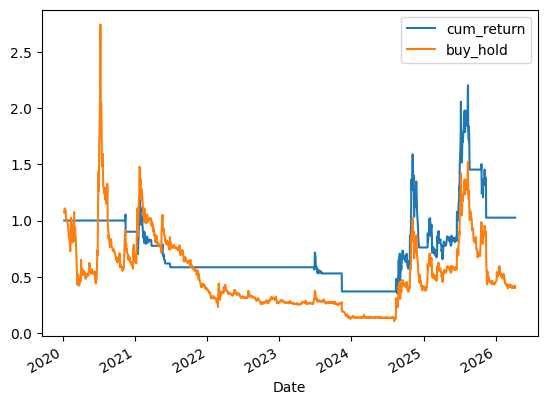

In [2]:
import yfinance as yf
import pandas as pd


#株価売買戦略

def load_stock_data(ticker):
    query = f"""
    SELECT *
    FROM stock_price
    WHERE ticker = '{ticker}'
    ORDER BY date
    """
    df = pd.read_sql(query, conn)
    df["date"] = pd.to_datetime(df["date"])
    return df



def create_signal(df):
    # 指標
    df["high_15"] = df["High"].rolling(15).max()
    df["low_30"] = df["Low"].rolling(30).min()
    df["vol_ma"] = df["Volume"].rolling(20).mean()
     # ===  トレンドフィルター追加 ===
    df["ma_25"] = df["Close"].rolling(25).mean()
    df["trend_flag"] = df["Close"] > df["ma_25"]
     # === 🔥 トレンド（長期） ===
    df["ma_200"] = df["Close"].rolling(200).mean()
    df["long_trend"] = df["Close"] > df["ma_200"]


    df["signal"] = pd.NA
    #買いサイン
    df.loc[(df["Close"] > df["high_15"].shift(1))&((df["Volume"] > df["vol_ma"]))&(df["trend_flag"])& (df["long_trend"]), "signal"] = 1
    #売りサイン
    df.loc[df["Close"] < df["low_30"].shift(1), "signal"] = 0
  # === 🔥 長期トレンド崩れたら即撤退 ===
    df.loc[df["Close"] < df["ma_200"], "signal"] = 0
    #改善①：短期損切り
    #df.loc[df["Close"] < df["entry_price"] * 0.95, "signal"] = 0

    # 改善②：利確（超重要）
    #df.loc[df["Close"] > df["entry_price"]* 1.1, "signal"] = 0

    #ポジション
    df["position"] = df["signal"].ffill().fillna(0).shift(1)

    df["new_entry"] = (df["position"] == 1) & (df["position"].shift(1) == 0)
     # === 🔥 entry_price作成 ===
    df["entry_price"] = pd.NA
    df.loc[df["new_entry"], "entry_price"] = df["Close"]
    df["entry_price"] = df["entry_price"].ffill()
    df.loc[df["position"] == 0, "entry_price"] = pd.NA
    #df = df.dropna()

    return df


results={}
tickers = ["7203.T", "3914.T", "7779.T", "2586.T"]
for ticker in tickers:
    df = yf.download(ticker, start="2020-01-01", interval="1D")
    df.columns = df.columns.get_level_values(0)
    df.columns.name = None
    df = create_signal(df)
    results[ticker] = df

for ticker, df in results.items():
    print(ticker)
    print(df["signal"].value_counts())

    df["return"] = df["Close"].pct_change()
    # 戦略リターン
    df["strategy_return"] = df["position"] * df["return"]
    # 累積
    df["cum_return"] = (1 + df["strategy_return"]).cumprod()
    # 比較
    df["buy_hold"] = (1 + df["return"]).cumprod()
    display(df.tail(5))
    print("エントリー回数:", df["new_entry"].sum())

    df[["cum_return", "buy_hold"]].plot()
    results[ticker] = df


export_cols = [
    "Close",
    "signal",
    "position",
    "new_entry",
    "entry_price",
    "strategy_return",
    "cum_return",
    "buy_hold"
]

with pd.ExcelWriter("backtest_results_all.xlsx") as writer:
    for ticker, df in results.items():
        df[export_cols].to_excel(writer, sheet_name=ticker.replace(".T", ""))    
